# Praktikum Pembelajaran Mesin - Pertemuan IV
## Random Forest and Ensemble Learning
### Bank Marketing Dataset - UCI

**Objectives:**
1. Understanding Random Forest for classification tasks
2. Preprocessing categorical and numerical data
3. Evaluating model performance using accuracy, confusion matrix, and classification report
4. Analyzing Feature Importance
5. Exploring Ensemble Learning using multiple classifiers
6. Handling imbalanced datasets using SMOTE


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

print("All libraries imported successfully!")


All libraries imported successfully!


## Step 2: Load Dataset

In [2]:
# Load the Bank Marketing Dataset
# Dataset source: https://archive.ics.uci.edu/dataset/222/bank+marketing
path = "bank-additional-full.csv"
data = pd.read_csv(path, sep=';')

print("Dataset Shape:", data.shape)
print("\nFirst 5 rows:")
data.head()


Dataset Shape: (41188, 21)

First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Dataset info
print("Dataset Info:")
print(data.info())
print("\nTarget variable distribution:")
print(data['y'].value_counts())
print("\nClass imbalance ratio:")
ratio = data['y'].value_counts()
print(f"  No  : {ratio['no']}  ({ratio['no']/len(data)*100:.1f}%)")
print(f"  Yes : {ratio['yes']}  ({ratio['yes']/len(data)*100:.1f}%)")


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   4

### Visualize Class Distribution

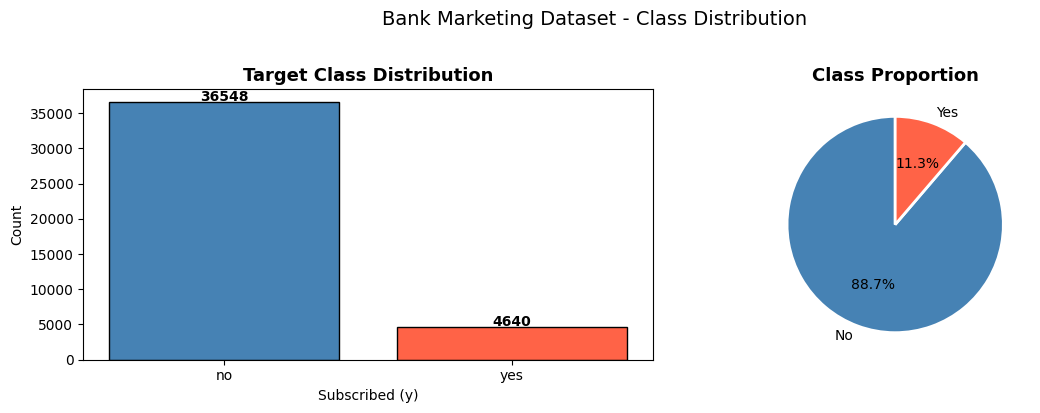

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
counts = data['y'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 200, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No', 'Yes'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Bank Marketing Dataset - Class Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Step 3: Data Preprocessing

In [5]:
# Check for missing values
print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")

# Remove rows with missing values
data.dropna(inplace=True)
print(f"\nDataset shape after dropping NaN: {data.shape}")


Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Total missing values: 0

Dataset shape after dropping NaN: (41188, 21)


### Encoding Categorical Features

In [6]:
# Encode categorical columns using LabelEncoder
label_encoder = LabelEncoder()
categorical_cols = data.select_dtypes(include=['object']).columns
print(f"Categorical columns ({len(categorical_cols)}): {list(categorical_cols)}")

for col in categorical_cols:
    data[col] = label_encoder.fit_transform(data[col])

print("\nAll categorical columns encoded successfully!")
print("\nData types after encoding:")
print(data.dtypes)


Categorical columns (11): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

All categorical columns encoded successfully!

Data types after encoding:
age                 int64
job                 int64
marital             int64
education           int64
default             int64
housing             int64
loan                int64
contact             int64
month               int64
day_of_week         int64
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome            int64
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                   int64
dtype: object


### Split Features and Target Variable

In [7]:
X = data.drop(columns=['y'])   # Features
y = data['y']                   # Target variable (0=No, 1=Yes)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget value counts:")
print(y.value_counts())


Features shape: (41188, 20)
Target shape: (41188,)

Target value counts:
y
0    36548
1     4640
Name: count, dtype: int64


### Normalizing Numerical Features

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features normalized using StandardScaler.")
print("Shape of scaled features:", X_scaled.shape)


Features normalized using StandardScaler.
Shape of scaled features: (41188, 20)


## Step 4: Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print(f"Training set size  : {X_train.shape[0]} samples")
print(f"Test set size      : {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest target distribution:")
print(pd.Series(y_test).value_counts())


Training set size  : 28831 samples
Test set size      : 12357 samples

Training target distribution:
y
0    25580
1     3251
Name: count, dtype: int64

Test target distribution:
y
0    10968
1     1389
Name: count, dtype: int64


## Step 5: Train Random Forest Classifier

In [10]:
clf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
clf.fit(X_train, y_train)

print("Random Forest model trained successfully!")
print(f"  n_estimators : {clf.n_estimators}")
print(f"  max_depth    : {clf.max_depth}")


Random Forest model trained successfully!
  n_estimators : 100
  max_depth    : 4


## Step 6: Model Evaluation

In [11]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Accuracy: 0.9042 (90.42%)

Confusion Matrix:
[[10899    69]
 [ 1115   274]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10968
           1       0.80      0.20      0.32      1389

    accuracy                           0.90     12357
   macro avg       0.85      0.60      0.63     12357
weighted avg       0.90      0.90      0.88     12357



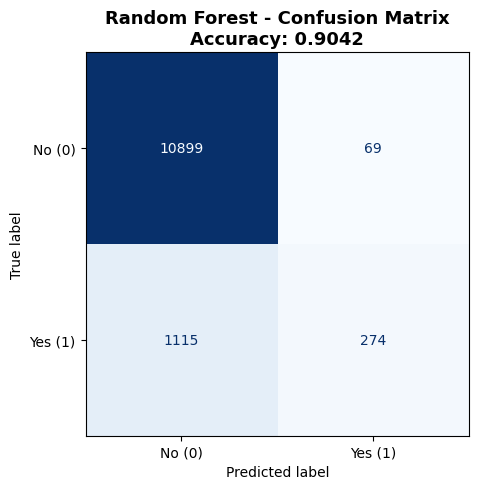

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['No (0)', 'Yes (1)'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Random Forest - Confusion Matrix\nAccuracy: {accuracy:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 7: Feature Importance Analysis

In [13]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(feature_importance.to_string(index=False))


Feature Importances:
       Feature  Importance
      duration    0.301264
   nr.employed    0.220468
     euribor3m    0.125854
         pdays    0.095479
      poutcome    0.073575
  emp.var.rate    0.051530
 cons.conf.idx    0.046188
cons.price.idx    0.034093
         month    0.017280
      previous    0.011726
           age    0.007383
       contact    0.007185
   day_of_week    0.002491
       default    0.001435
     education    0.001400
      campaign    0.001264
           job    0.000811
       marital    0.000379
       housing    0.000098
          loan    0.000097


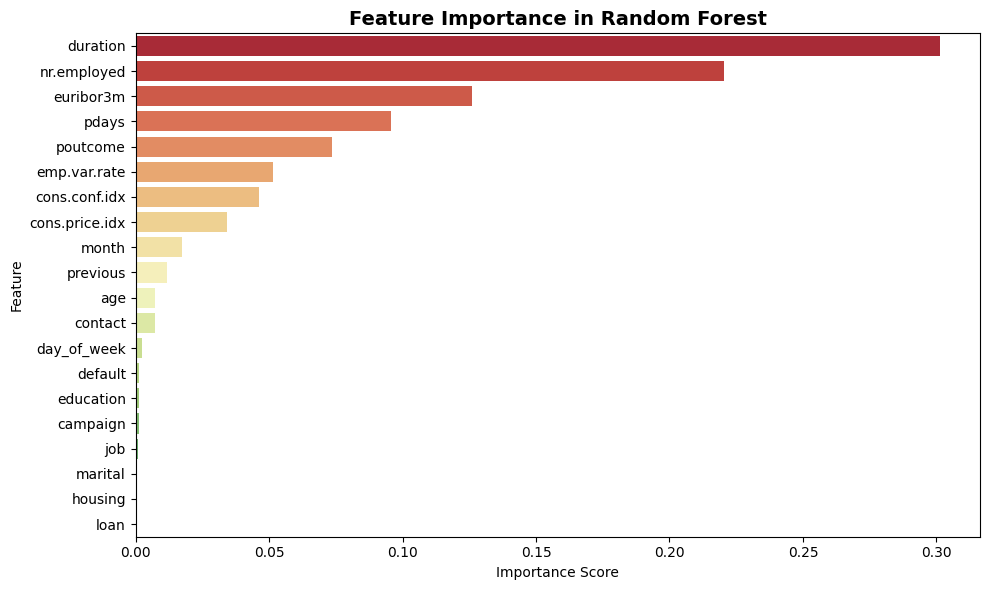

In [14]:
plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_importance)))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='RdYlGn')
plt.title('Feature Importance in Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## Step 8: Ensemble Learning with Multiple Classifiers

Ensemble learning combines multiple machine learning models to improve overall performance.
We use a **Voting Classifier** that combines:
- Logistic Regression
- Decision Tree
- Random Forest


In [15]:
# Define individual classifiers
clf1 = LogisticRegression(max_iter=1000, random_state=42)
clf2 = DecisionTreeClassifier(max_depth=4, random_state=42)
clf3 = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)

# Combine classifiers in a Voting Ensemble (Hard Voting)
ensemble = VotingClassifier(estimators=[
    ('lr', clf1),
    ('dt', clf2),
    ('rf', clf3)
], voting='hard')

ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)

accuracy_lr   = accuracy_score(y_test, clf1.fit(X_train, y_train).predict(X_test))
accuracy_dt   = accuracy_score(y_test, clf2.fit(X_train, y_train).predict(X_test))
accuracy_rf   = accuracy_score(y_test, clf3.fit(X_train, y_train).predict(X_test))
accuracy_ens  = accuracy_score(y_test, y_pred_ensemble)

print("=" * 45)
print("      Model Accuracy Comparison")
print("=" * 45)
print(f"  Logistic Regression   : {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"  Decision Tree         : {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
print(f"  Random Forest         : {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"  Voting Ensemble       : {accuracy_ens:.4f} ({accuracy_ens*100:.2f}%)")
print("=" * 45)


      Model Accuracy Comparison
  Logistic Regression   : 0.9102 (91.02%)
  Decision Tree         : 0.9122 (91.22%)
  Random Forest         : 0.9042 (90.42%)
  Voting Ensemble       : 0.9093 (90.93%)


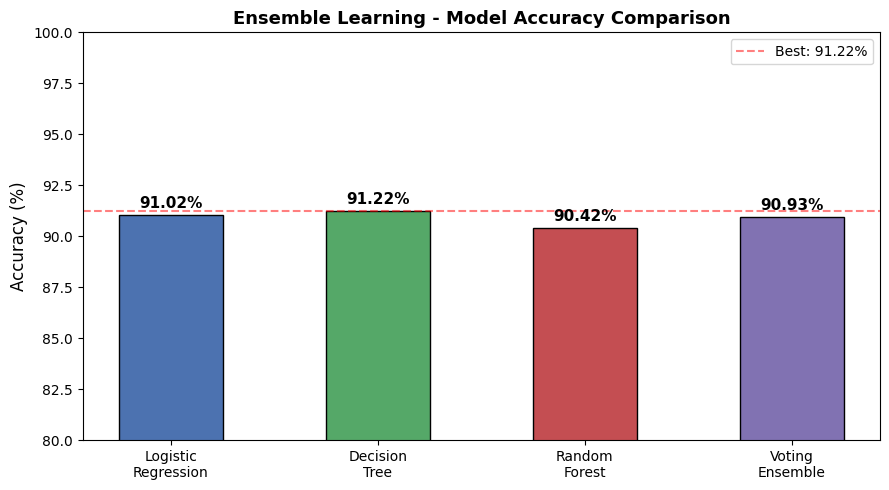

In [16]:
models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'Voting\nEnsemble']
accuracies = [accuracy_lr, accuracy_dt, accuracy_rf, accuracy_ens]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models, [a * 100 for a in accuracies], color=colors, edgecolor='black', width=0.5)
ax.set_ylim(80, 100)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Ensemble Learning - Model Accuracy Comparison', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.axhline(y=max(accuracies)*100, color='red', linestyle='--', alpha=0.5, label=f'Best: {max(accuracies)*100:.2f}%')
ax.legend()
plt.tight_layout()
plt.show()


## Step 9: Handling Imbalanced Data with SMOTE

Since the dataset is imbalanced (most clients did **not** subscribe), we apply **SMOTE** 
(Synthetic Minority Over-sampling Technique) to balance the classes before training.


In [17]:
print("Class distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts())
print(f"  Imbalance ratio: {pd.Series(y_train).value_counts()[0]/pd.Series(y_train).value_counts()[1]:.2f}:1")

# Apply SMOTE only on training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_resampled).value_counts())
print(f"  Imbalance ratio: {pd.Series(y_resampled).value_counts()[0]/pd.Series(y_resampled).value_counts()[1]:.2f}:1")


Class distribution BEFORE SMOTE:
y
0    25580
1     3251
Name: count, dtype: int64
  Imbalance ratio: 7.87:1

Class distribution AFTER SMOTE:
y
0    25580
1    25580
Name: count, dtype: int64
  Imbalance ratio: 1.00:1


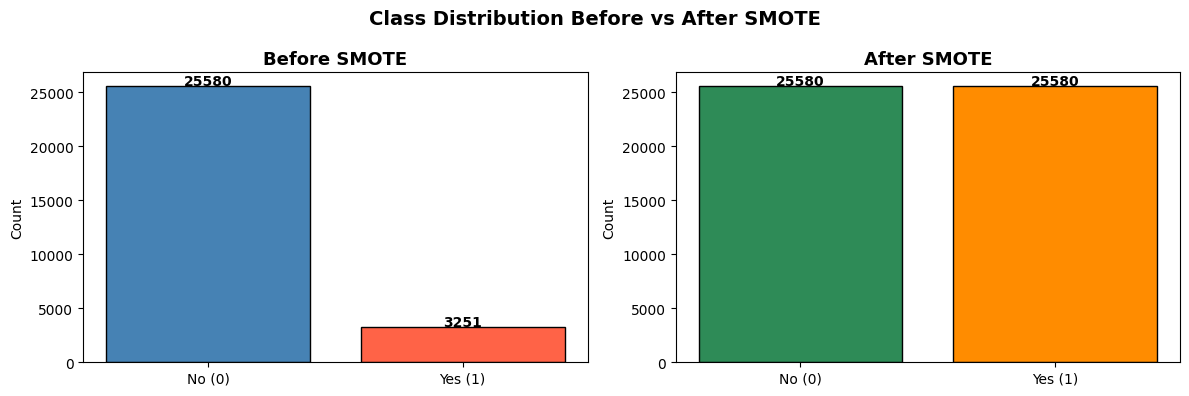

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = pd.Series(y_train).value_counts()
after  = pd.Series(y_resampled).value_counts()

for ax, counts, title, colors in zip(
    axes,
    [before, after],
    ['Before SMOTE', 'After SMOTE'],
    [['steelblue', 'tomato'], ['seagreen', 'darkorange']]
):
    bars = ax.bar(['No (0)', 'Yes (1)'], counts.values, color=colors, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                str(val), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Train Random Forest with SMOTE-balanced Data

In [19]:
# Train Random Forest on SMOTE-resampled training data
clf_smote = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42)
clf_smote.fit(X_resampled, y_resampled)

# Evaluate on original (unmodified) test set
y_pred_smote = clf_smote.predict(X_test)

accuracy_smote = accuracy_score(y_test, y_pred_smote)
conf_matrix_smote = confusion_matrix(y_test, y_pred_smote)

print("=" * 50)
print("   Random Forest + SMOTE - Evaluation Results")
print("=" * 50)
print(f"Accuracy: {accuracy_smote:.4f} ({accuracy_smote*100:.2f}%)")
print("\nConfusion Matrix:")
print(conf_matrix_smote)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))


   Random Forest + SMOTE - Evaluation Results
Accuracy: 0.8975 (89.75%)

Confusion Matrix:
[[9992  976]
 [ 291 1098]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     10968
           1       0.53      0.79      0.63      1389

    accuracy                           0.90     12357
   macro avg       0.75      0.85      0.79     12357
weighted avg       0.92      0.90      0.91     12357



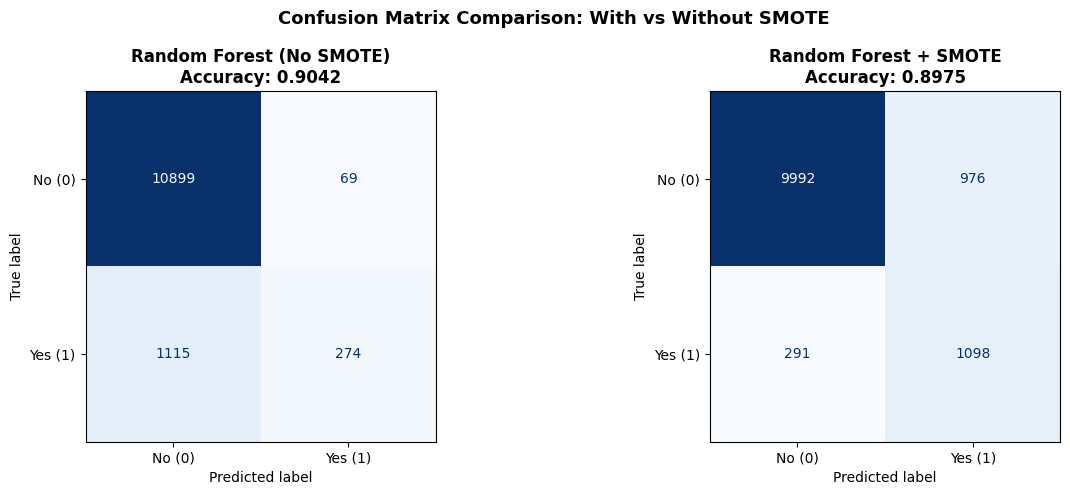

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm, title, acc in zip(
    axes,
    [conf_matrix, conf_matrix_smote],
    ['Random Forest (No SMOTE)', 'Random Forest + SMOTE'],
    [accuracy, accuracy_smote]
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'{title}\nAccuracy: {acc:.4f}', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison: With vs Without SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 10: Final Model Comparison Summary

In [21]:
print("=" * 55)
print("          FINAL PERFORMANCE SUMMARY")
print("=" * 55)
results = {
    'Logistic Regression'        : accuracy_lr,
    'Decision Tree'              : accuracy_dt,
    'Random Forest (no SMOTE)'   : accuracy_rf,
    'Voting Ensemble'            : accuracy_ens,
    'Random Forest + SMOTE'      : accuracy_smote,
}
for model, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(acc * 40)
    print(f"  {model:<30} {acc:.4f}  {bar}")
print("=" * 55)
print(f"\n  Best model: {max(results, key=results.get)}")
print(f"  Best accuracy: {max(results.values()):.4f} ({max(results.values())*100:.2f}%)")


          FINAL PERFORMANCE SUMMARY
  Decision Tree                  0.9122  ████████████████████████████████████
  Logistic Regression            0.9102  ████████████████████████████████████
  Voting Ensemble                0.9093  ████████████████████████████████████
  Random Forest (no SMOTE)       0.9042  ████████████████████████████████████
  Random Forest + SMOTE          0.8975  ███████████████████████████████████

  Best model: Decision Tree
  Best accuracy: 0.9122 (91.22%)


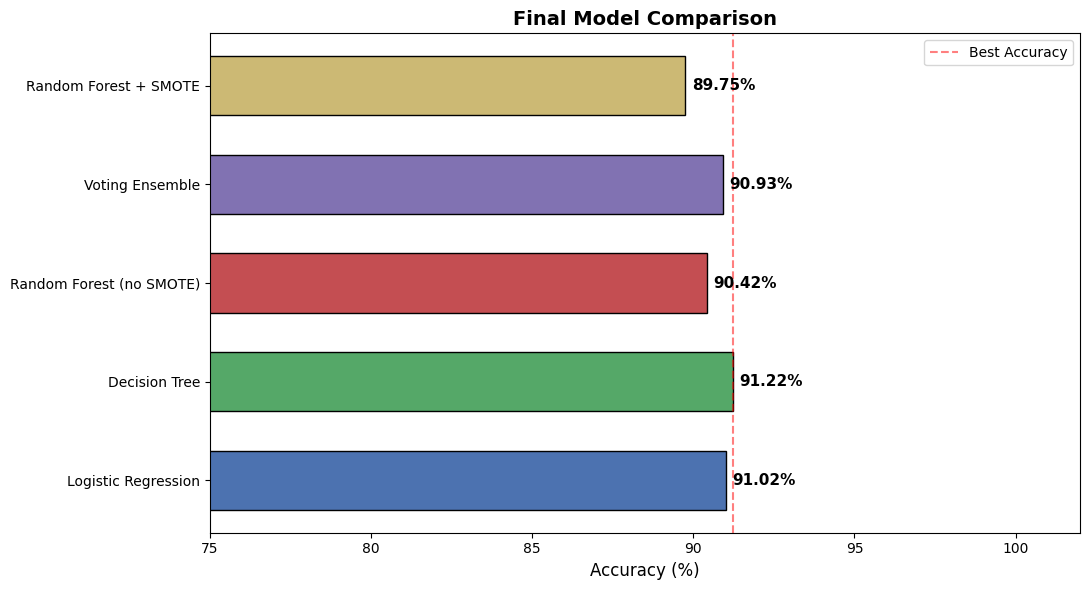

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))
models_all = list(results.keys())
accs_all   = list(results.values())
palette    = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
bars = ax.barh(models_all, [a * 100 for a in accs_all], color=palette, edgecolor='black', height=0.6)
ax.set_xlim(75, 102)
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Final Model Comparison', fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accs_all):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{acc*100:.2f}%', va='center', fontweight='bold', fontsize=11)
ax.axvline(x=max(accs_all)*100, color='red', linestyle='--', alpha=0.5, label='Best Accuracy')
ax.legend()
plt.tight_layout()
plt.show()


## Conclusion

✅ **Random Forest Classifier** was trained on the Bank Marketing Dataset.

✅ **Model Evaluation** was performed using Accuracy, Confusion Matrix, and Classification Report.

✅ **Feature Importance** analysis was conducted to identify key predictors.

✅ **Ensemble Learning** (Voting Classifier) was implemented combining Logistic Regression, Decision Tree, and Random Forest.

✅ **SMOTE** was applied to handle class imbalance, improving recall for the minority class (subscribed clients).

### Key Takeaways:
- **Random Forest** outperforms single Decision Trees by reducing variance through bagging
- **Ensemble methods** can further boost accuracy by combining diverse classifiers  
- **SMOTE** significantly improves the model's ability to detect minority class samples (clients who subscribe), which is critical in marketing scenarios
- **Feature importance** helps identify the most influential variables (e.g., `duration`, `nr.employed`)
